In [1]:
import numpy as np
from pydrake.all import (
    DiagramBuilder,
    Linearize,
    LinearQuadraticRegulator,
    MeshcatVisualizer,
    SceneGraph,
    Simulator,
    StartMeshcat,
    WrapToSystem,
    LeafSystem,
    BasicVector,
    Saturation,
)
from pydrake.examples import AcrobotGeometry, AcrobotPlant, AcrobotState

import matplotlib.pyplot as plt
from pydrake.all import LogVectorOutput # 专门用于记录仿真数据的系统

# 启动可视化服务器 (保持 Module 1 的初始化逻辑)
try:
    meshcat = StartMeshcat()
except:
    pass # 避免重复运行报错

INFO:drake:Meshcat listening for connections at https://de71cef0-406f-4385-b8bc-5f4cd79581df.deepnoteproject.com/7000/
Installing NginX server for MeshCat on Deepnote...


# Target Statue And LQR

该部分代码定义了目标状态参量，实现了LQR控制增益计算逻辑函数，返回增益矩阵K

In [2]:
# 1. 目标状态定义 
def UprightState():
    state = AcrobotState()
    state.set_theta1(np.pi)      # 第一摆杆向上
    state.set_theta2(0.0)        # 第二摆杆与第一摆杆直线对齐
    state.set_theta1dot(0.0)
    state.set_theta2dot(0.0)
    return state

# 2. LQR 控制增益计算逻辑 
def GetBalancingGain():
    """
    计算并在直立点返回 LQR 增益矩阵 K。
    关键 BalancingLQR 的参数设定 Q 和 R。
    """
    acrobot = AcrobotPlant()
    context = acrobot.CreateDefaultContext()
    
    # 设定平衡点参考输入
    acrobot.get_input_port(0).FixValue(context, [0.0])
    
    # 设定平衡点参考位置
    context.get_mutable_continuous_state_vector().SetFromVector(
        UprightState().CopyToVector()
    )

    # 设定权重矩阵
    Q = np.diag(([10.0, 10.0, 1.0, 1.0]))
    R = np.array([1.0])

    # 求解 LQR 并显式提取 K 矩阵 (为了在切换控制器中使用，提取数值矩阵)
    lqr_system = LinearQuadraticRegulator(acrobot, context, Q, R)
    K = -lqr_system.D() # 对应线性反馈 u = -K(x - x_star)
    return K

# Acrobot Swingup And LQR Balance

该段代码实现了Acrobot运用能量泵算法和LQR算法实现在从底部垂悬状态到顶部平衡状态的完整流程仿真模拟

## 核心控制器类，集成了能量泵和LQR切换逻辑

In [3]:

# 3. 核心控制器类：集成能量成型与 LQR 切换 
class AcrobotSwingupAndBalanceController(LeafSystem):
    def __init__(self, plant, K_lqr):
        LeafSystem.__init__(self)
        self.plant = plant
        self.K_lqr = K_lqr # 接收来自 GetBalancingGain() 计算得到的增益
        self.plant_context = self.plant.CreateDefaultContext()


        #记录上一步是否进入LQR
        self.is_lqr_active = False 
        #记录每次进入LQR的时间
        self.lqr_entrance_times = []
        #记录每次退出LQR时间
        self.lqr_exit_times = []

        #acrobot的基础参数
        self.m1, self.m2, self.l1, self.lc1, self.lc2, self.g = 1, 1, 1, 0.5, 1, 9.81
        self.I1, self.I2 = 0.083, 0.33

        
        # 预计算目标直立点的总能量
        self.E_up = self.m1 * self.g * self.lc1 + self.m2 * self.g * (self.l1 + self.lc2)

        # 定义输入端口（接收状态向量 x）
        self.DeclareVectorInputPort("state", 4)
        # 定义输出端口（输出力矩 u）
        self.DeclareVectorOutputPort("torque", 1, self.CalcControlOutput)

    # 计算当前状态的总能量
    def _CalculateEnergy(self, x):

        q1, q2, q1d, q2d = x
        
        # 1. 势能 V (参考 PDF 第 7 页)
        V = -self.m1 * self.g * self.lc1 * np.cos(q1) - \
             self.m2 * self.g * (self.l1 * np.cos(q1) + self.lc2 * np.cos(q1 + q2))
             
        # 2. 动能 T = 0.5 * v^T * M(q) * v
        M11 = self.I1 + self.I2 + self.m1 * self.lc1**2 + \
              self.m2 * (self.l1**2 + self.lc2**2 + 2 * self.l1 * self.lc2 * np.cos(q2))
        M12 = self.I2 + self.m2 * (self.lc2**2 + self.l1 * self.lc2 * np.cos(q2))
        M22 = self.I2 + self.m2 * self.lc2**2
        
        T = 0.5 * (M11 * q1d**2 + 2 * M12 * q1d * q2d + M22 * q2d**2)
        return T + V

    # 核心控制逻辑
    def CalcControlOutput(self, context, output):
        # 1. 获取当前状态 [theta1, theta2, theta1_dot, theta2_dot]
        x = self.get_input_port(0).Eval(context)
        q1, q2, q1_dot, q2_dot = x
        
        # 2. 计算当前总能量
        E_current = self._CalculateEnergy(x)
        
        # 3. 计算相对于平衡点的误差 (处理 theta1 的 2pi 周期)
        err_theta1 = (q1 - np.pi + np.pi) % (2.0 * np.pi) - np.pi
        energy_error = E_current - self.E_up  # 与目标能量的差值

        # 判定是否满足【进入】LQR 的条件 (严一点)
        enter_lqr = np.abs(err_theta1) < 0.25 and np.abs(energy_error) < 1.0
        # 判定是否满足【离开】LQR 的条件 (松一点，防止反复横跳)
        exit_lqr = np.abs(err_theta1) > 0.5 or np.abs(energy_error) > 1.5

        # --- 控制权决定 ---
        if not self.is_lqr_active:
            if enter_lqr:
                self.is_lqr_active = True
                #print(">> 捕获成功！切入 LQR 控制模式")  #调试时使用，方便观察何时进入LQR
                current_time = context.get_time()
                self.lqr_entrance_times.append(current_time)
        else:
            if exit_lqr:
                self.is_lqr_active = False
                #print("<< 丢弃！偏离过大，切回泵能模式") #调试时使用，方便观察何时退出LQR
                current_time = context.get_time()
                self.lqr_exit_times.append(current_time)
        # --- 核心切换逻辑 (Switching Logic, 任务 4) ---
        # 判定准则：角度接近向上 且 能量偏差较小
        # 这就是你 Module 3 代码只能维持而不能上升的根本区别：动态判定进入“吸引域”
        if self.is_lqr_active:
            # 【A 阶段：LQR 平衡控制】
            x_star = UprightState().CopyToVector()
            error_state = x - x_star
            # 对 theta1,theta2 做周期性修正
            error_state[0] = (error_state[0] + np.pi) % (2 * np.pi) - np.pi
            error_state[1] = (error_state[1] + np.pi) % (2 * np.pi) - np.pi
            u = -self.K_lqr.dot(error_state) 

        else:
            # 【B 阶段：能量成型控制】 
            # 通过被动关节(肩部)的速度来决定泵能方向
            # 泵能律：当能量不足时，在利于能量增加的方向施加力矩
            k = 10
            if np.abs(energy_error) > 2.0:  # 当能量差距较大时，使用更激进的控制策略
                kp_straight = 15.0
                u_pump = k * np.tanh(2.0 * q1_dot) * energy_error
            else: 
                kp_straight = 15.0
                u_pump = k * q1_dot * energy_error

            # 直立律：当角度偏离时，施加力矩使角度趋近于直立
            kd_straight = 2.0
            u_straight = -kp_straight * q2 - kd_straight * q2_dot

            u = u_pump + u_straight

        output.SetAtIndex(0, u)




## 主仿真环境搭建

仿真启动：正在执行从底部开始的摆起动作...
/tmp/ipykernel_107/990656220.py:109: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output.SetAtIndex(0, u)
仿真结束。
第 1 次进入 LQR 的时间: 2.3414 秒
第 2 次进入 LQR 的时间: 4.1553 秒
第 3 次进入 LQR 的时间: 4.1811 秒
第 4 次进入 LQR 的时间: 4.1938 秒
第 5 次进入 LQR 的时间: 4.1975 秒
第 6 次进入 LQR 的时间: 19.1780 秒
第 7 次进入 LQR 的时间: 27.9466 秒
第 8 次进入 LQR 的时间: 27.9940 秒
第 9 次进入 LQR 的时间: 28.0048 秒
第 10 次进入 LQR 的时间: 28.0057 秒
第 11 次进入 LQR 的时间: 28.0245 秒
第 12 次进入 LQR 的时间: 28.0361 秒
第 13 次进入 LQR 的时间: 28.0346 秒
第 14 次进入 LQR 的时间: 28.0555 秒
第 15 次进入 LQR 的时间: 28.0622 秒
第 16 次进入 LQR 的时间: 28.0911 秒
第 17 次进入 LQR 的时间: 28.0938 秒
第 18 次进入 LQR 的时间: 28.1020 秒
第 19 次进入 LQR 的时间: 28.1094 秒
第 20 次进入 LQR 的时间: 28.1094 秒
第 21 次进入 LQR 的时间: 28.1201 秒
第 22 次进入 LQR 的时间: 28.1187 秒
第 23 次进入 LQR 的时间: 28.1195 秒
第 24 次进入 LQR 的时间: 28.1357 秒
第 25 次进入 LQR 的时间: 28.1342 秒
第

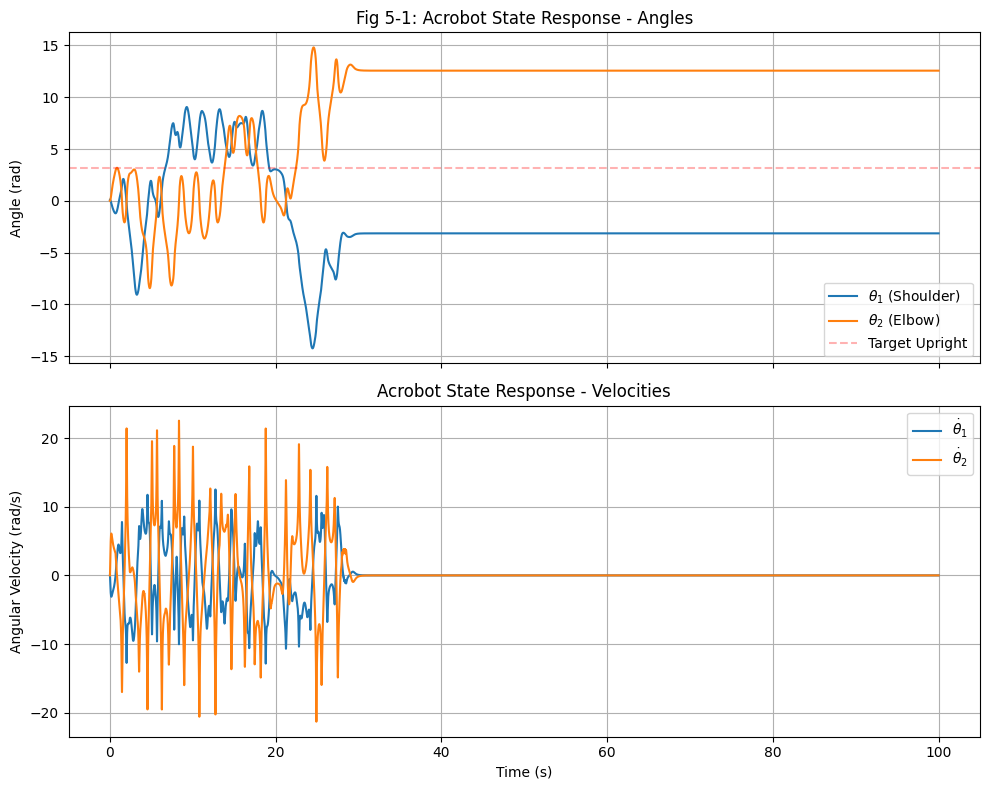

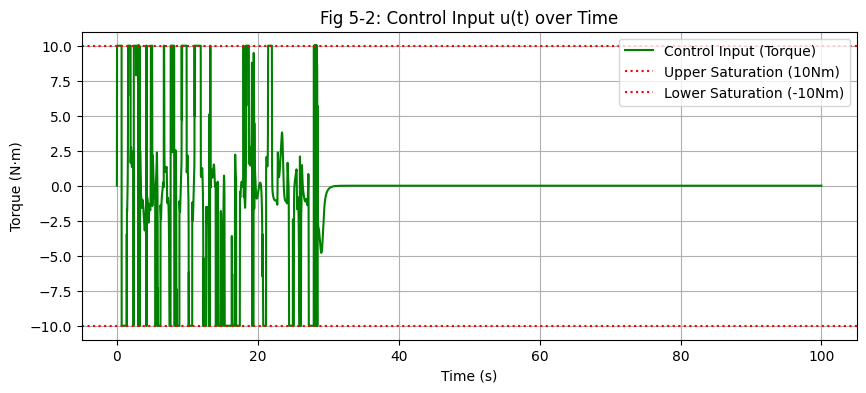

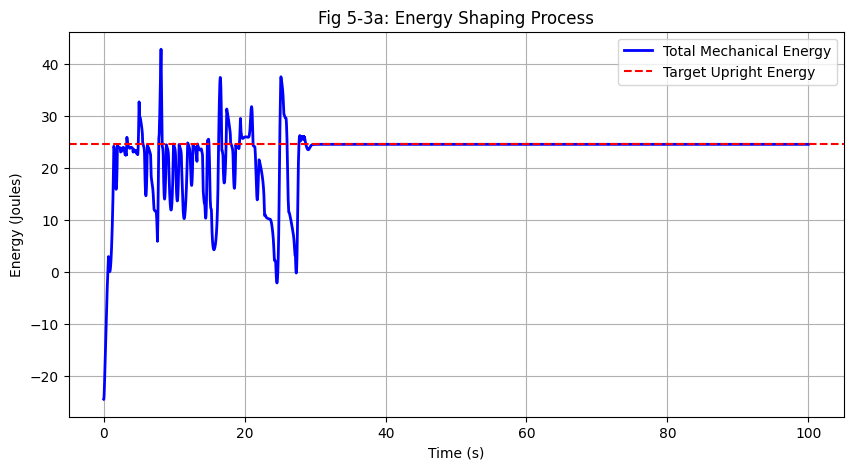

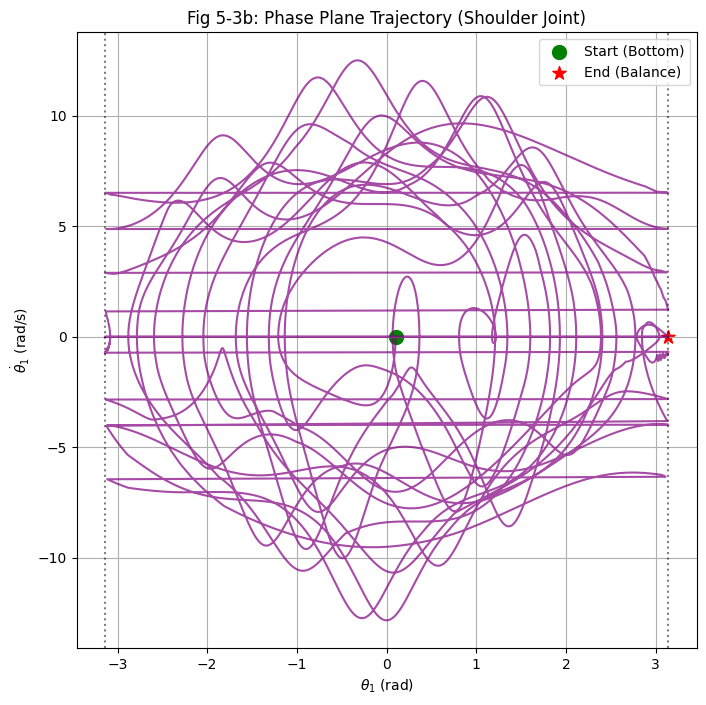

In [4]:
# 4. 主仿真环境搭建
def acrobot_swingup_project():
    builder = DiagramBuilder()
    
    # 实例化双摆系统
    acrobot = builder.AddSystem(AcrobotPlant())
    
    # 计算 LQR 增益
    K_matrix = GetBalancingGain()
    
    # 实例化自定义切换控制器
    controller = builder.AddSystem(AcrobotSwingupAndBalanceController(acrobot, K_matrix))
    
    # 添加力矩限幅约束
    # 摆起过程对电机挑战巨大，限幅确保仿真严谨。
    saturation = builder.AddSystem(Saturation(min_value=[-10], max_value=[10]))
    
    # 系统连接 (Diagram Connection)
    builder.Connect(acrobot.get_output_port(0), controller.get_input_port(0))
    builder.Connect(controller.get_output_port(0), saturation.get_input_port(0))
    builder.Connect(saturation.get_output_port(0), acrobot.get_input_port(0))
    
    # 状态记录
    state_logger = LogVectorOutput(acrobot.get_output_port(0), builder)
    # u(t)记录
    torque_logger = LogVectorOutput(saturation.get_output_port(0), builder)

    # 设置 Meshcat 可视化
    scene_graph = builder.AddSystem(SceneGraph())
    AcrobotGeometry.AddToBuilder(builder, acrobot.get_output_port(0), scene_graph)
    meshcat.Delete()
    MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)

    diagram = builder.Build()
    simulator = Simulator(diagram)
    context = simulator.get_mutable_context()

    # 5. 初始状态设置 
    # [x1, x2, x3, x4] = [肩角, 肘角, 肩速, 肘速]
    # 设置为自然下垂位置 [0, 0, 0, 0]
    context.SetContinuousState([0.1, 0.0, 0.0, 0.0]) # 稍微偏离垂直位置，避免奇异点
    
    # 仿真执行设置
    simulator.set_target_realtime_rate(1.0) # 建议先 1:1 观察，现象剧烈时可改为 0.5
    
    print("仿真启动：正在执行从底部开始的摆起动作...")
    simulator.AdvanceTo(100.0) # 设置仿真总时间30s
    print("仿真结束。")
    if controller.lqr_entrance_times:
        for i, t in enumerate(controller.lqr_entrance_times):
            print(f"第 {i+1} 次进入 LQR 的时间: {t:.4f} 秒")
        print(f"总计切换次数: {len(controller.lqr_entrance_times)}")
        print(f"第一次成功摆起时间: {controller.lqr_entrance_times[0]:.2f} 秒")
    else:
        print("仿真时间内未能进入 LQR 模式")
    print("="*30)
    if controller.lqr_exit_times:
        for i, t in enumerate(controller.lqr_entrance_times):
            print(f"第 {i+1} 次退出 LQR 的时间: {t:.4f} 秒")
        print(f"总计切换次数: {len(controller.lqr_entrance_times)}")
    print("="*30)

    # 提取记录的数据
    log = state_logger.FindLog(context)
    t_data = log.sample_times()      # 时间轴数据
    x_data = log.data()             # 状态数据 (4, N) 的矩阵

    # --- 开始绘制 图 5-1 ---
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # 1. 角度曲线 (theta1, theta2)
    axs[0].plot(t_data, x_data[0, :], label=r'$\theta_1$ (Shoulder)')
    axs[0].plot(t_data, x_data[1, :], label=r'$\theta_2$ (Elbow)')
    axs[0].axhline(y=np.pi, color='r', linestyle='--', alpha=0.3, label='Target Upright')
    axs[0].set_ylabel('Angle (rad)')
    axs[0].set_title('Fig 5-1: Acrobot State Response - Angles')
    axs[0].legend()
    axs[0].grid(True)

    # 2. 角速度曲线 (theta1_dot, theta2_dot)
    axs[1].plot(t_data, x_data[2, :], label=r'$\dot{\theta}_1$')
    axs[1].plot(t_data, x_data[3, :], label=r'$\dot{\theta}_2$')
    axs[1].set_ylabel('Angular Velocity (rad/s)')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_title('Acrobot State Response - Velocities')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.savefig("fig5_1.png")
    plt.show()

    # --- 开始绘制 图 5-2 ---
    u_log = torque_logger.FindLog(context)
    u_t_data = u_log.sample_times()
    u_data = u_log.data().flatten() # 控制量通常是 1 维

    plt.figure(figsize=(10, 4))
    plt.plot(u_t_data, u_data, label='Control Input (Torque)', color='green')
    
    # 绘制饱和边界参考线，扭矩受限
    plt.axhline(y=10, color='r', linestyle=':', label='Upper Saturation (10Nm)')
    plt.axhline(y=-10, color='r', linestyle=':', label='Lower Saturation (-10Nm)')

    plt.title('Fig 5-2: Control Input u(t) over Time')
    plt.xlabel('Time (s)')
    plt.ylabel('Torque (N·m)')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig5_2.png") 
    plt.show()
    

    #---  开始绘制 图5-3 ---
    # 定义与控制器中一致的物理参数
    m1, m2, l1, lc1, lc2, g = 1, 1, 1, 0.5, 1, 9.81
    I1, I2 = 0.083, 0.33
    # 目标能量 (Upright Energy)
    E_up = m1 * g * lc1 + m2 * g * (l1 + lc2)
    
    # 遍历 log 数据计算每一帧的能量
    energies = []
    q1_data = x_data[0, :]
    q2_data = x_data[1, :]
    v1_data = x_data[2, :]
    v2_data = x_data[3, :]

    for i in range(len(t_data)):
        q1, q2, q1d, q2d = q1_data[i], q2_data[i], v1_data[i], v2_data[i]
        # 1. 势能 V
        V = -m1 * g * lc1 * np.cos(q1) - m2 * g * (l1 * np.cos(q1) + lc2 * np.cos(q1 + q2))
        # 2. 惯性矩阵分量
        M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2))
        M12 = I2 + m2 * (lc2**2 + l1 * lc2 * np.cos(q2))
        M22 = I2 + m2 * lc2**2
        # 3. 动能 T
        T = 0.5 * (M11 * q1d**2 + 2 * M12 * q1d * q2d + M22 * q2d**2)
        energies.append(T + V)   

    # --- 绘图：图 5-3a 能量曲线 ---
    plt.figure(figsize=(10, 5))
    plt.plot(t_data, energies, label='Total Mechanical Energy', color='blue', linewidth=2)
    plt.axhline(y=E_up, color='red', linestyle='--', label='Target Upright Energy')
    plt.title('Fig 5-3a: Energy Shaping Process')
    plt.xlabel('Time (s)')
    plt.ylabel('Energy (Joules)')
    plt.legend()
    plt.grid(True)
    plt.savefig("fig5_3a.png")
    plt.show()



    # --- 绘图：图 5-3b 相平面轨迹 (q1 vs q1_dot) ---
    plt.figure(figsize=(8, 8))
    # 对 q1 进行回绕处理，确保轨迹集中在 [-pi, pi] 观察顶点切换
    q1_wrapped_plot = (q1_data + np.pi) % (2 * np.pi) - np.pi
    
    plt.plot(q1_wrapped_plot, v1_data, color='purple', alpha=0.7)
    # 标注起点和终点
    plt.scatter(q1_wrapped_plot[0], v1_data[0], color='green', s=100, label='Start (Bottom)')
    plt.scatter(q1_wrapped_plot[-1], v1_data[-1], color='red', s=100, marker='*', label='End (Balance)')
    
    plt.title('Fig 5-3b: Phase Plane Trajectory (Shoulder Joint)')
    plt.xlabel(r'$\theta_1$ (rad)')
    plt.ylabel(r'$\dot{\theta}_1$ (rad/s)')
    plt.axvline(x=np.pi, color='black', linestyle=':', alpha=0.5) # 顶点位置线1
    plt.axvline(x=-np.pi, color='black', linestyle=':', alpha=0.5) # 顶点位置线2
    plt.legend()
    plt.grid(True)
    plt.savefig("fig5_3b.png")
    plt.show() 
    
  
# 执行主项目
if __name__ == "__main__":
    acrobot_swingup_project()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=de71cef0-406f-4385-b8bc-5f4cd79581df' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>